In [9]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("data/X_train.csv")
X_test = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").values.ravel()
y_test = pd.read_csv("data/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(29165, 47) (7292, 47) (29165,) (7292,)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.5673340647284696

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.58      0.70      6434
           1       0.14      0.50      0.21       858

    accuracy                           0.57      7292
   macro avg       0.52      0.54      0.46      7292
weighted avg       0.81      0.57      0.64      7292


Confusion Matrix:
 [[3709 2725]
 [ 430  428]]


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.6856829402084477

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      6434
           1       0.17      0.43      0.24       858

    accuracy                           0.69      7292
   macro avg       0.54      0.57      0.52      7292
weighted avg       0.82      0.69      0.74      7292


Confusion Matrix:
 [[4632 1802]
 [ 490  368]]


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200, max_depth=10)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7449259462424574

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84      6434
           1       0.24      0.52      0.33       858

    accuracy                           0.74      7292
   macro avg       0.58      0.65      0.58      7292
weighted avg       0.84      0.74      0.78      7292


Confusion Matrix:
 [[4984 1450]
 [ 410  448]]


In [13]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle class imbalance (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=200,
    max_depth=6,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7885353812397148

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87      6434
           1       0.30      0.62      0.41       858

    accuracy                           0.79      7292
   macro avg       0.62      0.72      0.64      7292
weighted avg       0.87      0.79      0.82      7292


Confusion Matrix:
 [[5218 1216]
 [ 326  532]]


                 Model  Accuracy  Precision (Risky)  Recall (Risky)  \
0  Logistic Regression  0.567334           0.135744        0.498834   
1        Decision Tree  0.685683           0.169585        0.428904   
2        Random Forest  0.744926           0.236038        0.522145   
3              XGBoost  0.788535           0.304348        0.620047   

   F1 (Risky)  
0    0.213413  
1    0.243065  
2    0.325109  
3    0.408289  


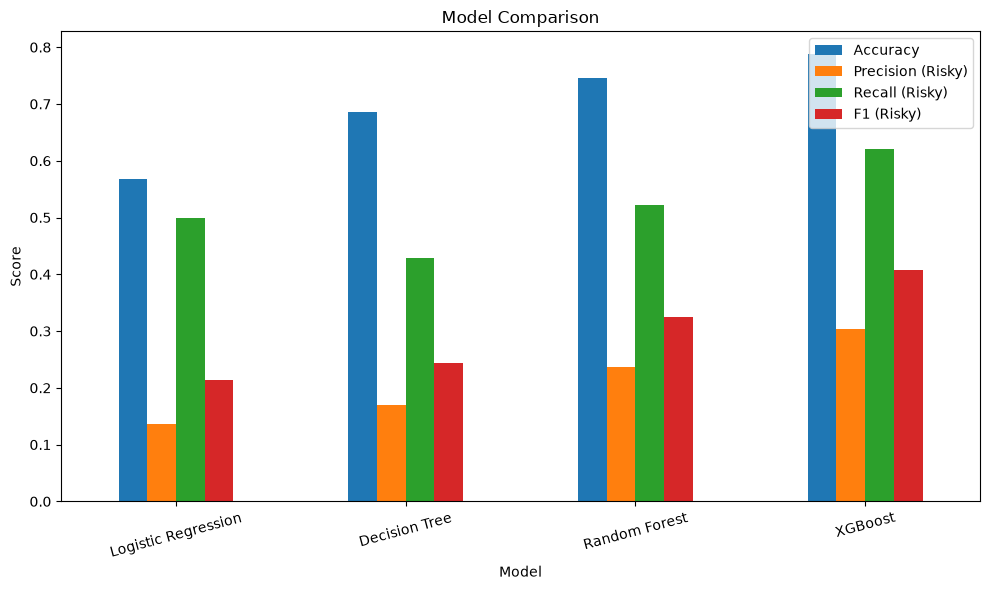

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

results = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

summary = []
for name, preds in results.items():
    summary.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Risky)': precision_score(y_test, preds, pos_label=1),
        'Recall (Risky)': recall_score(y_test, preds, pos_label=1),
        'F1 (Risky)': f1_score(y_test, preds, pos_label=1)
    })

results_df = pd.DataFrame(summary)
print(results_df)

results_df.set_index('Model')[['Accuracy', 'Precision (Risky)', 'Recall (Risky)', 'F1 (Risky)']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(xgb_model, "credit_approval_model.pkl")

# Also save the column order, since Flask app needs to build input in the exact same column structure
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

print("Model and columns saved successfully")

Model and columns saved successfully
